In [2]:
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import os
import glob
import pyarrow as pa
import pyarrow.parquet as pq
import matplotlib as plt

import matplotlib.pyplot as plt
import seaborn as sns
import textwrap

In [ ]:
#file locations
parquet_file_paths={
    "patient": r"Client_Data_files\Parquets\synthetic_patients.parquet",
    "encounter": r"Client_Data_files\Parquets\synthetic_encounters.parquet",
    "hospitals": r"Client_Data_files\Parquets\synthetic_hospitals.parquet",
    "provider": r"Client_Data_files\Parquets\synthetic_providers.parquet",    
}

In [ ]:
#reading the parquet files
patient_df = pd.read_parquet(parquet_file_paths['patient'])
encounter_df = pd.read_parquet(parquet_file_paths['encounter'])
hospital_df = pd.read_parquet(parquet_file_paths['hospitals'])
provider_df = pd.read_parquet(parquet_file_paths['provider'])



In [ ]:
# Creating a data map for easy access
data_map={
    "patient": patient_df,
    "encounter": encounter_df,
    "hospitals": hospital_df,
    "provider": provider_df
}

In [14]:
for key, df in data_map.items():
    print(f"Dataframe: {key}")
    print(f"Shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")    
    for col in df.columns:
        if df[col].isna().sum() > 0:
            print(f"Column '{col}' has {df[col].isna().sum()} missing values.")
    print("")

Dataframe: patient
Shape: (100000, 16)
Columns: ['patient_id', 'first_name', 'last_name', 'date_of_birth', 'gender', 'race', 'ethnicity', 'primary_language', 'zip_code', 'insurance_type', 'household_income', 'education_level', 'age', 'cultural_background', 'preferred_provider_language', 'cultural_preferences']

Dataframe: encounter
Shape: (200000, 17)
Columns: ['encounter_id', 'patient_id', 'provider_id', 'encounter_date', 'encounter_type', 'primary_diagnosis', 'length_of_stay', 'total_cost', 'cultural_background', 'primary_language', 'languages_spoken', 'cultural_competency_rating', 'cultural_match_score', 'language_match', 'patient_satisfaction', 'treatment_adherence', 'return_visit_30_days']

Dataframe: hospitals
Shape: (200, 14)
Columns: ['hospital_id', 'hospital_name', 'hospital_type', 'zip_code', 'bed_count', 'teaching_hospital', 'trauma_center', 'language_services_available', 'cultural_competency_program', 'interpreter_services_24_7', 'community_health_programs', 'overall_rating

Performing Univariate Analysis...


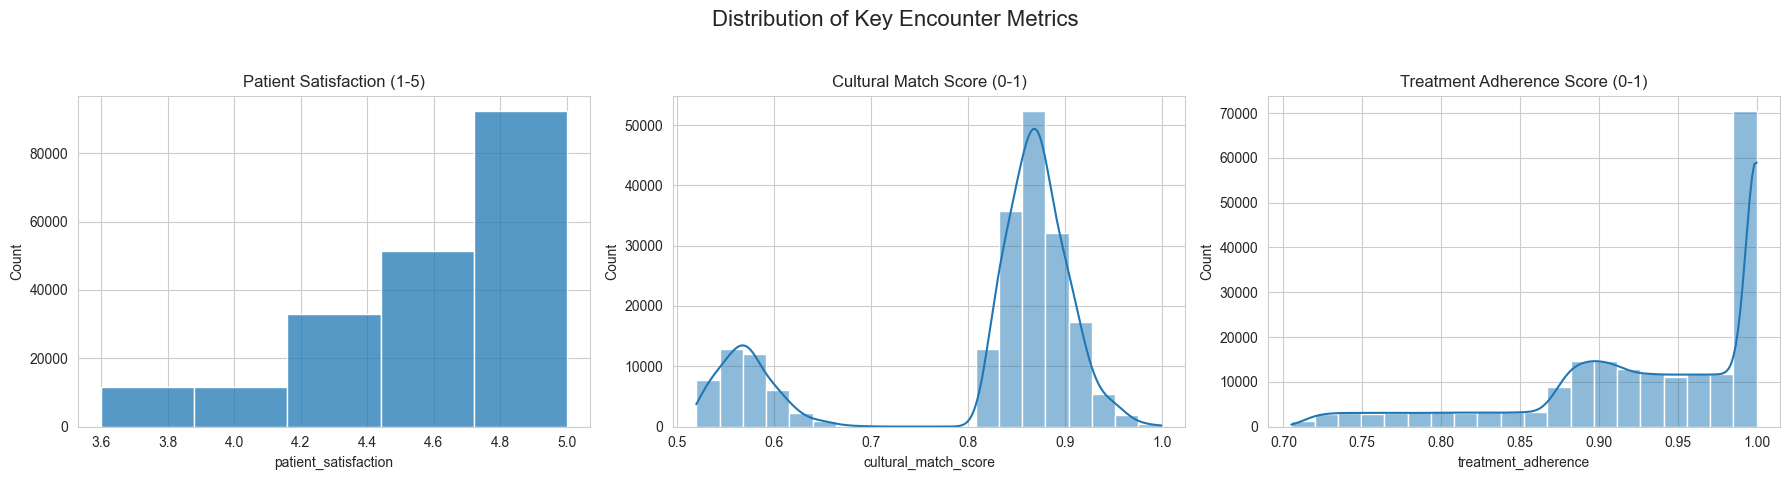

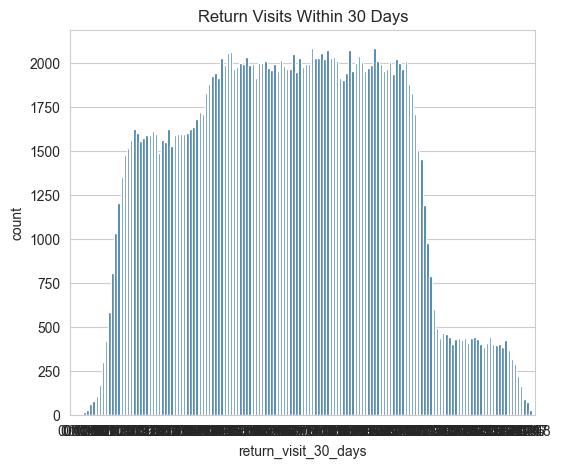

In [15]:
# --- 1. Univariate Analysis ---
print("Performing Univariate Analysis...")
sns.set_style("whitegrid")

# Create a figure for the histograms
plt.figure(figsize=(18, 5))
plt.suptitle('Distribution of Key Encounter Metrics', fontsize=16)

# Plot histogram for patient_satisfaction
plt.subplot(1, 3, 1)
sns.histplot(encounter_df['patient_satisfaction'], bins=5, kde=False)
plt.title('Patient Satisfaction (1-5)')

# Plot histogram for cultural_match_score
plt.subplot(1, 3, 2)
sns.histplot(encounter_df['cultural_match_score'], bins=20, kde=True)
plt.title('Cultural Match Score (0-1)')

# Plot histogram for treatment_adherence
plt.subplot(1, 3, 3)
sns.histplot(encounter_df['treatment_adherence'], bins=20, kde=True)
plt.title('Treatment Adherence Score (0-1)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Create a bar chart for return_visit_30_days
plt.figure(figsize=(6, 5))
sns.countplot(x='return_visit_30_days', data=encounter_df)
plt.title('Return Visits Within 30 Days')
plt.show()



Performing Bivariate Analysis...


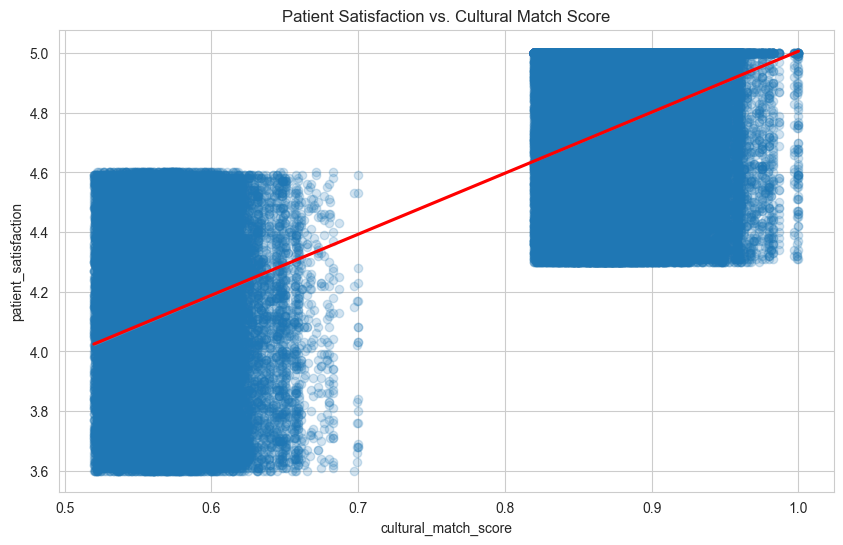

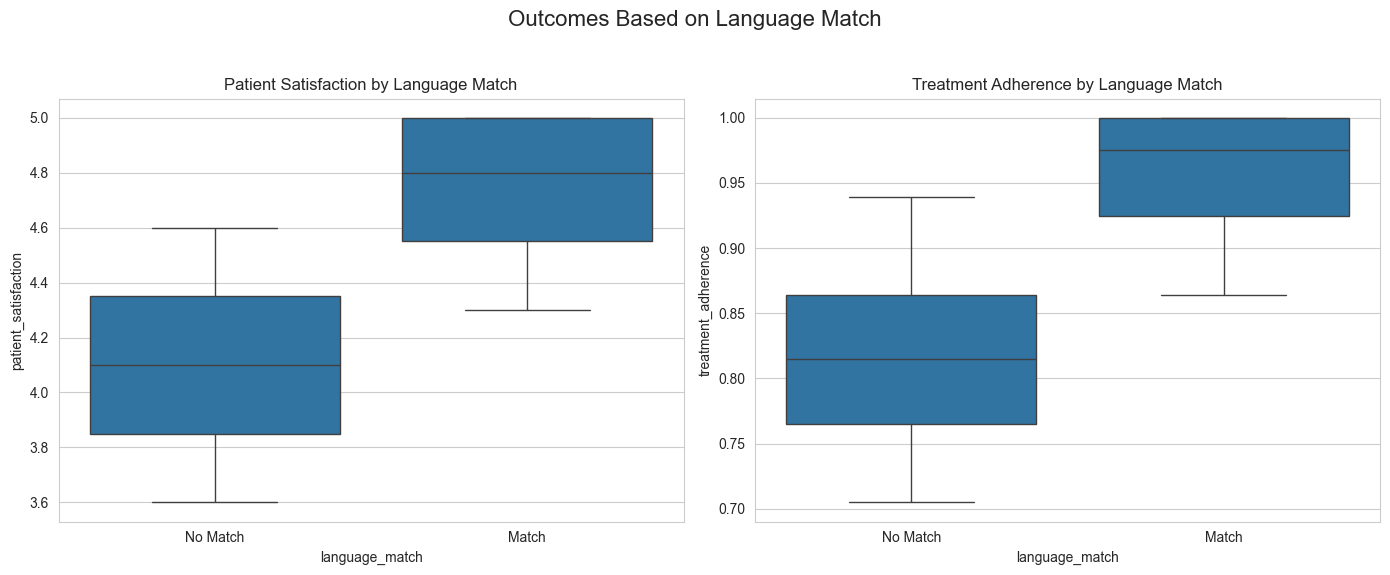

In [16]:
# --- 2. Bivariate Analysis ---
print("\nPerforming Bivariate Analysis...")

# Scatter plot for cultural_match_score vs. patient_satisfaction
plt.figure(figsize=(10, 6))
sns.regplot(data=encounter_df, x='cultural_match_score', y='patient_satisfaction',
            scatter_kws={'alpha':0.2}, line_kws={'color':'red'})
plt.title('Patient Satisfaction vs. Cultural Match Score')
plt.show()

# Box plots for language_match vs. outcomes
plt.figure(figsize=(14, 6))
plt.suptitle('Outcomes Based on Language Match', fontsize=16)

# Box plot for language_match vs. patient_satisfaction
plt.subplot(1, 2, 1)
sns.boxplot(data=encounter_df, x='language_match', y='patient_satisfaction')
plt.title('Patient Satisfaction by Language Match')
plt.xticks([0, 1], ['No Match', 'Match'])

# Box plot for language_match vs. treatment_adherence
plt.subplot(1, 2, 2)
sns.boxplot(data=encounter_df, x='language_match', y='treatment_adherence')
plt.title('Treatment Adherence by Language Match')
plt.xticks([0, 1], ['No Match', 'Match'])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()



Performing Multivariate Analysis...


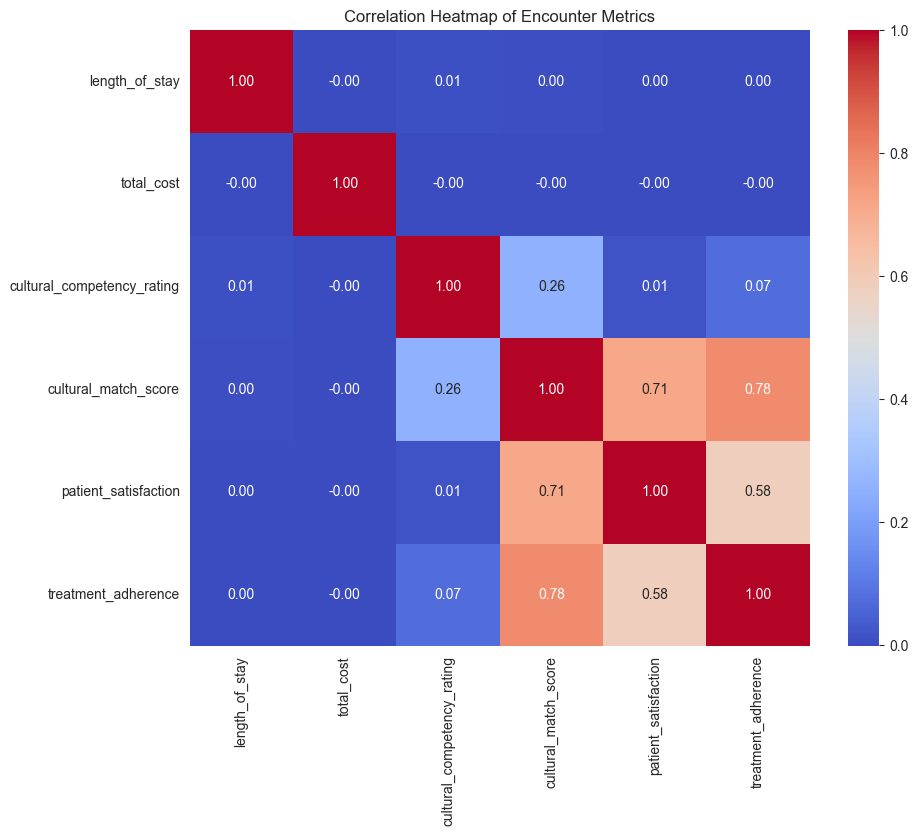

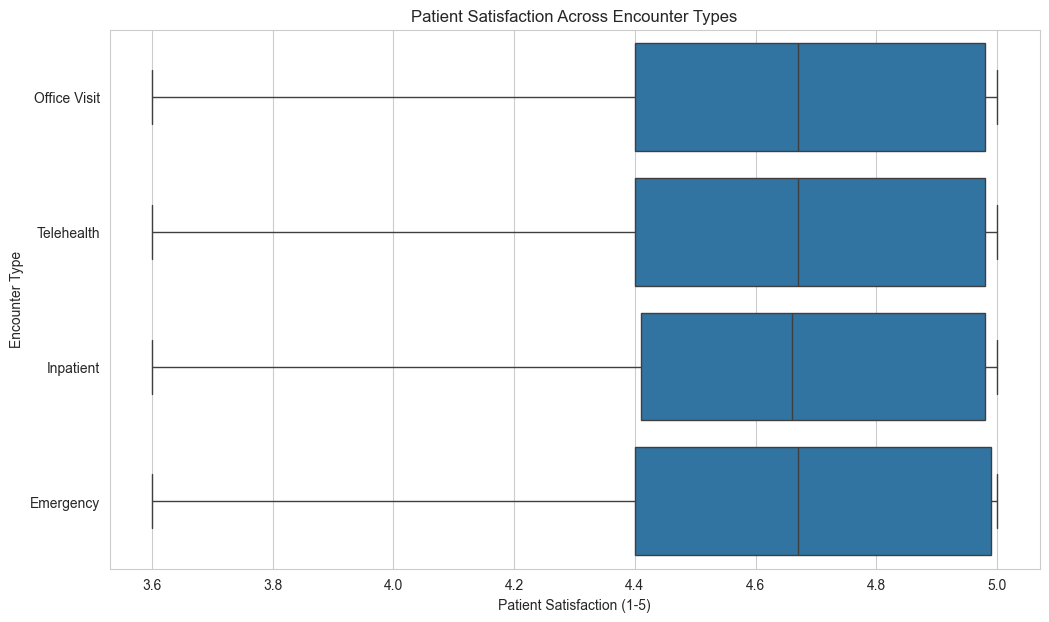

In [17]:
# --- 3. Multivariate Analysis ---
print("\nPerforming Multivariate Analysis...")

# Correlation heatmap
numerical_cols = encounter_df.select_dtypes(include=['float64', 'int64']).columns
cols_to_exclude = ['encounter_id', 'patient_id', 'provider_id', 'language_match', 'return_visit_30_days']
corr_cols = [col for col in numerical_cols if col not in cols_to_exclude]

plt.figure(figsize=(10, 8))
sns.heatmap(encounter_df[corr_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Encounter Metrics')
plt.show()

# Box plots for patient_satisfaction across encounter_type
plt.figure(figsize=(12, 7))
sns.boxplot(data=encounter_df, x='patient_satisfaction', y='encounter_type')
plt.title('Patient Satisfaction Across Encounter Types')
plt.xlabel('Patient Satisfaction (1-5)')
plt.ylabel('Encounter Type')
plt.show()


In [24]:
# number of unique doctors in encounters
print(encounter_df['provider_id'].nunique())
print(data_map['provider']['provider_id'].nunique())

5000
5000


In [21]:
# number of repeated encounters between a patient and doctor pair:
print(encounter_df.groupby(['patient_id', 'provider_id']).size().value_counts())

1    199928
2        36
Name: count, dtype: int64


In [26]:
print(data_map['patient']['cultural_preferences'].value_counts()/len(data_map['patient']))

cultural_preferences
No Specific Preference                                 0.43097
Culturally Similar Provider                            0.34735
Same Language Provider                                 0.12263
Culturally Similar Provider; Same Language Provider    0.09905
Name: count, dtype: float64
